This code generates a matrix using networkx with a specific degree sequence and then runs the co-occurrnece simulation, infers the network, and compares the degree sequence rank between nodes for the interaction and co-occurrence networks.

In [ ]:
import csv
import numpy as np
from importlib import reload
import networkx as nx
from sklearn import metrics
from scipy.stats import rankdata
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, spearmanr, pearsonr
import pickle, os # to save data

import metaCommunityMx
import run_cooccurrence
reload(metaCommunityMx)
reload(run_cooccurrence)

os.makedirs('figure_data', exist_ok=True)

# for random matrix
interactFactor = 1/5
pPositive = 0.1
nSpec = 100

# for modular matrix 
nModules = 5
pWithinMod = 0.9
pBetweenMod = 0.1

# for hub
pHub = 0.9
pWithinModHub = 0.001
pBetweenModHub = 0.001

# for nested
pInterInteract = 1
pIntraInteract = 0.2

# parms for GLV sim
alpha = 0.001 
#samplesize = int(0.5 * nSpec) # number of species to sample
interactStren = alpha * interactFactor
samplesize = nSpec//2 # number of species to sample
numtrials = 500
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))
cutoffalpha = 0.01

In [2]:
# Get interaction matrices 
G_exp, mx_exp = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type = "exponential", expected_degree = 10, pPositive = pPositive)
G_power, mx_power = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type = "power", expected_degree = 10, pPositive = pPositive)
G_random, mx_random = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type = "random", expected_degree = 10, pPositive = pPositive)

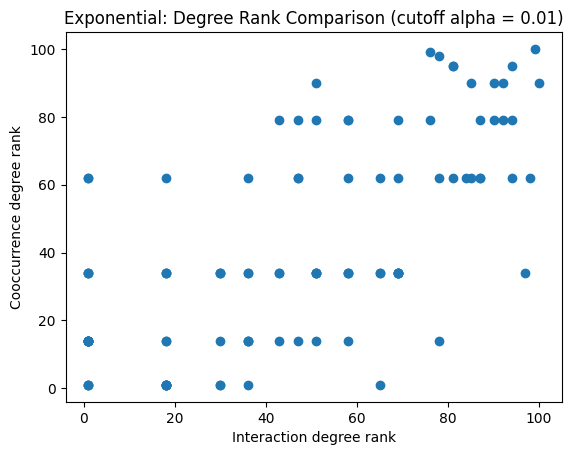

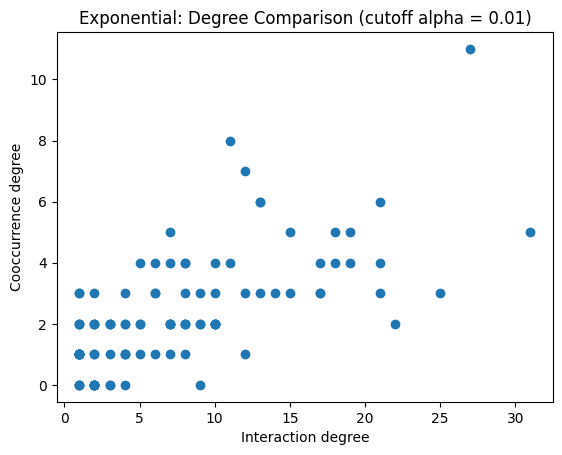

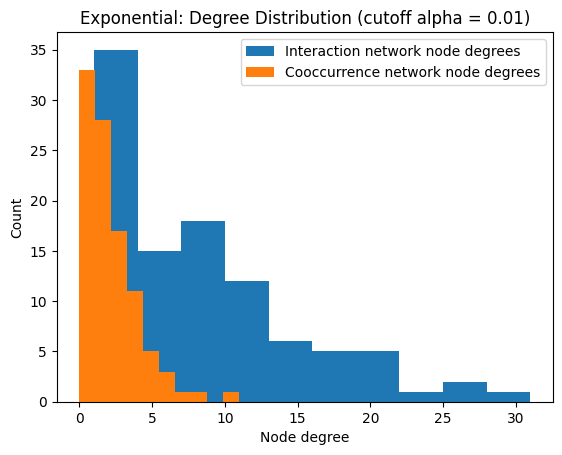

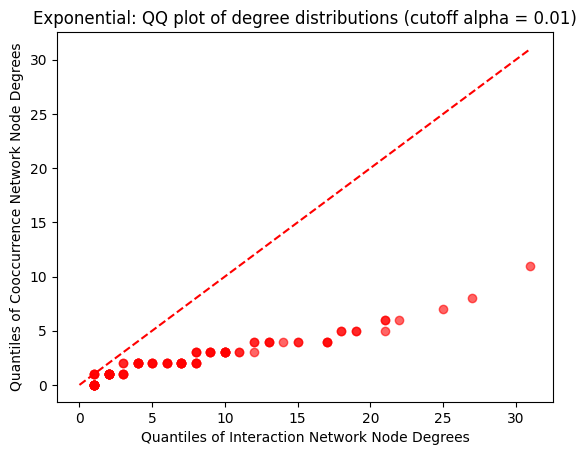

In [ ]:
# get coocurrence matrix and plot for exponential

network_exp, G_coocc_exp = run_cooccurrence.get_coocc_network(interactionMx = mx_exp, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax=200, pval_alpha=cutoffalpha)

# Get degrees and ranks
deg_exp_interact = np.array([d for n, d in G_exp.degree()])
deg_exp_cooc = np.array([d for n, d in G_coocc_exp.degree()])

rank_exp_interact = rankdata(deg_exp_interact, method='min')
rank_exp_cooc = rankdata(deg_exp_cooc, method='min')

with open('figure_data/dsr_exp.pkl', 'wb') as f:
    pickle.dump({
        'deg_interact': deg_exp_interact,
        'deg_cooc': deg_exp_cooc,
        'rank_interact': rank_exp_interact,
        'rank_cooc': rank_exp_cooc,
        'cutoffalpha': cutoffalpha,
        'label': 'Exponential',
    }, f)

plt.scatter(rank_exp_interact, rank_exp_cooc)
plt.xlabel('Interaction degree rank')
plt.ylabel('Cooccurrence degree rank')
plt.title(f'Exponential: Degree Rank Comparison (cutoff alpha = {np.round(cutoffalpha,2)})')
plt.show()

plt.scatter(deg_exp_interact, deg_exp_cooc)
plt.xlabel('Interaction degree')
plt.ylabel('Cooccurrence degree')
plt.title(f'Exponential: Degree Comparison (cutoff alpha = {np.round(cutoffalpha,2)})')
plt.show()

plt.hist(deg_exp_interact, label = "Interaction network node degrees")
plt.hist(deg_exp_cooc, label = "Cooccurrence network node degrees")
plt.xlabel('Node degree')
plt.ylabel('Count')
plt.title(f'Exponential: Degree Distribution (cutoff alpha = {np.round(cutoffalpha,2)})')
plt.legend()
plt.show()

## QQ plot
q1 = np.quantile(np.sort(deg_exp_interact), np.linspace(0, 1, len(deg_exp_interact)))
q2 = np.quantile(np.sort(deg_exp_cooc), np.linspace(0, 1, len(deg_exp_interact)))
plt.scatter(q1, q2, alpha=0.6, c="red")
plt.plot([min(q1.min(), q2.min()), max(q1.max(), q2.max())], 
            [min(q1.min(), q2.min()), max(q1.max(), q2.max())], 'r--')
plt.title(f'Exponential: QQ plot of degree distributions (cutoff alpha = {np.round(cutoffalpha,2)})')
plt.xlabel('Quantiles of Interaction Network Node Degrees')
plt.ylabel('Quantiles of Cooccurrence Network Node Degrees')
plt.show()

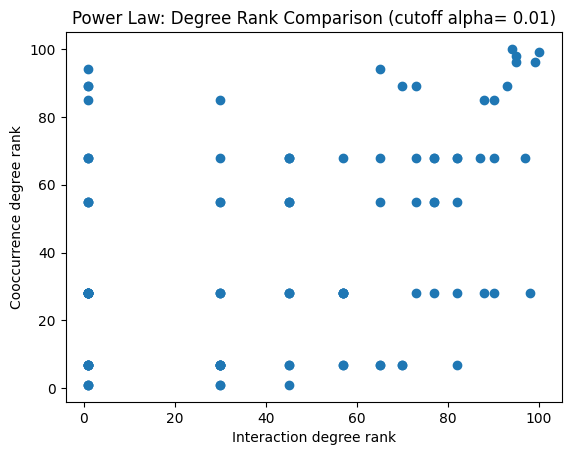

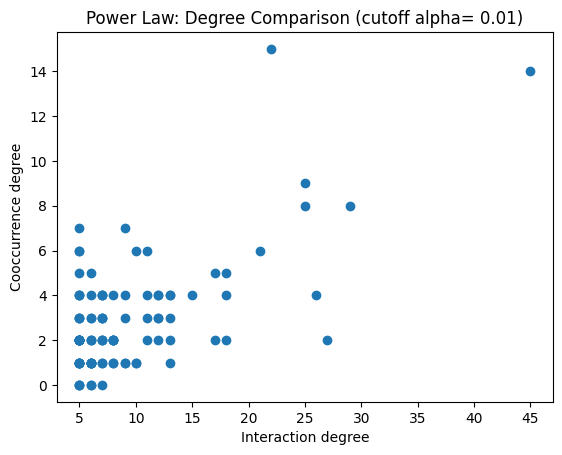

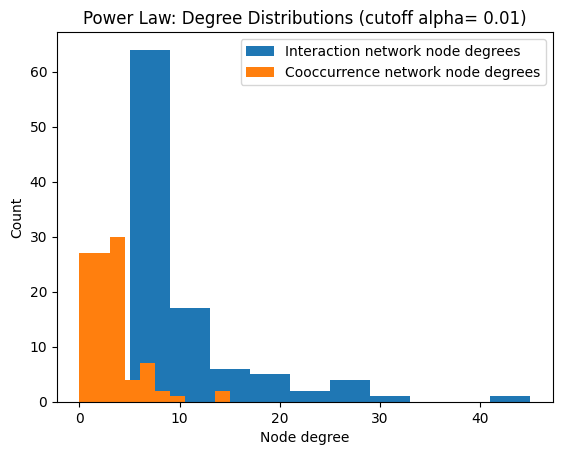

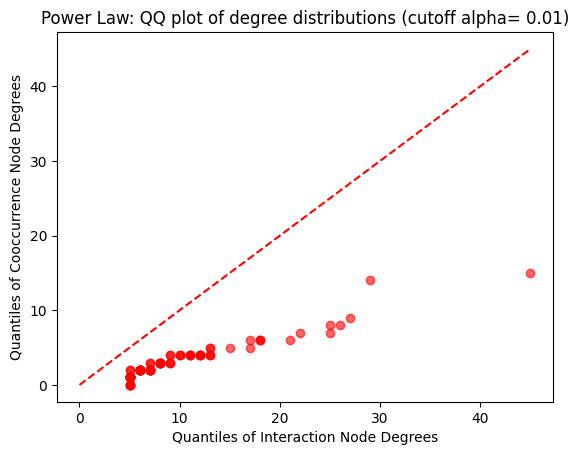

In [ ]:
# plot for power law

network_pow, G_coocc_pow = run_cooccurrence.get_coocc_network(interactionMx = mx_power, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax=200, pval_alpha=cutoffalpha)

# Get degrees and ranks
deg_pow_interact = np.array([d for n, d in G_power.degree()])
deg_pow_cooc = np.array([d for n, d in G_coocc_pow.degree()])

rank_pow_interact = rankdata(deg_pow_interact, method='min')
rank_pow_cooc = rankdata(deg_pow_cooc, method='min')

with open('figure_data/dsr_pow.pkl', 'wb') as f:
    pickle.dump({
        'deg_interact': deg_pow_interact,
        'deg_cooc': deg_pow_cooc,
        'rank_interact': rank_pow_interact,
        'rank_cooc': rank_pow_cooc,
        'cutoffalpha': cutoffalpha,
        'label': 'Power Law',
    }, f)

plt.scatter(rank_pow_interact, rank_pow_cooc)
plt.xlabel('Interaction degree rank')
plt.ylabel('Cooccurrence degree rank')
plt.title(f'Power Law: Degree Rank Comparison (cutoff alpha= {np.round(cutoffalpha,2)})')
plt.show()

plt.scatter(deg_pow_interact, deg_pow_cooc)
plt.xlabel('Interaction degree')
plt.ylabel('Cooccurrence degree')
plt.title(f'Power Law: Degree Comparison (cutoff alpha= {np.round(cutoffalpha,2)})')
plt.show()

plt.hist(deg_pow_interact, label = "Interaction network node degrees")
plt.hist(deg_pow_cooc, label = "Cooccurrence network node degrees")
plt.xlabel('Node degree')
plt.ylabel('Count')
plt.title(f'Power Law: Degree Distributions (cutoff alpha= {np.round(cutoffalpha,2)})')
plt.legend()
plt.show()

## QQ plot
q1 = np.quantile(np.sort(deg_pow_interact), np.linspace(0, 1, len(deg_pow_interact)))
q2 = np.quantile(np.sort(deg_pow_cooc), np.linspace(0, 1, len(deg_pow_interact)))
plt.scatter(q1, q2, alpha=0.6, c="red")
plt.plot([min(q1.min(), q2.min()), max(q1.max(), q2.max())], 
            [min(q1.min(), q2.min()), max(q1.max(), q2.max())], 'r--')
plt.title(f'Power Law: QQ plot of degree distributions (cutoff alpha= {np.round(cutoffalpha,2)})')
plt.xlabel('Quantiles of Interaction Node Degrees')
plt.ylabel('Quantiles of Cooccurrence Node Degrees')
plt.show()

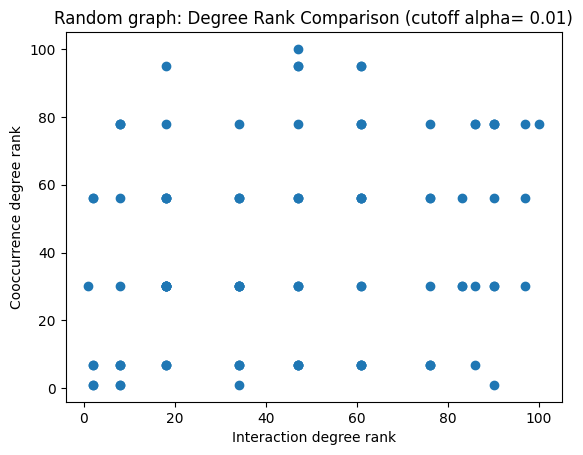

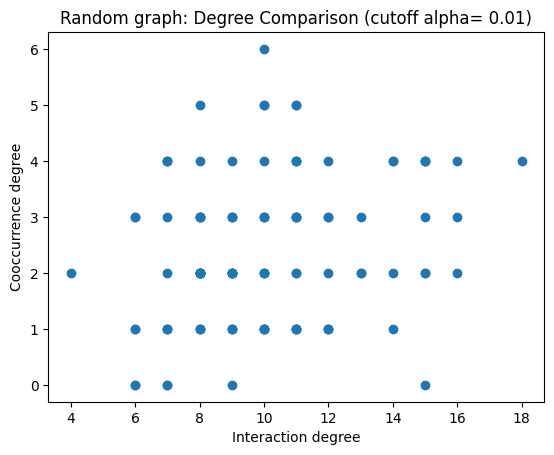

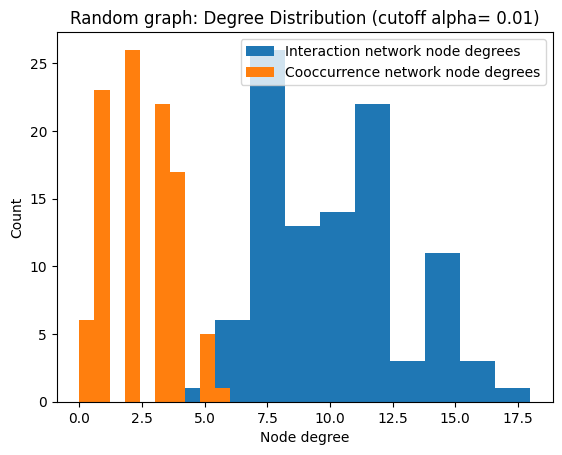

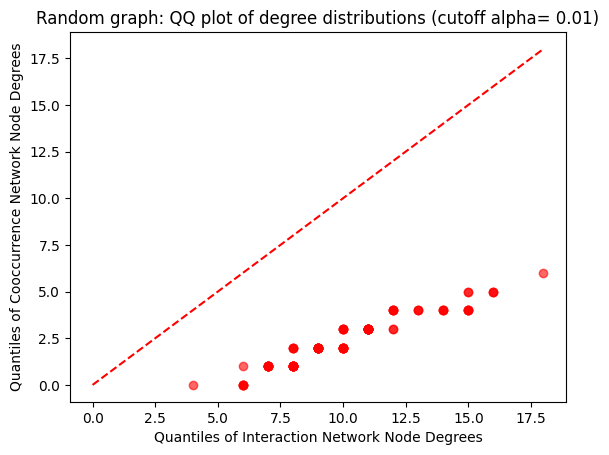

In [ ]:
# plots for random graphs

network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = mx_random, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax=200, pval_alpha=cutoffalpha)

# Get degrees and ranks
deg_rand_interact = np.array([d for n, d in G_random.degree()])
deg_rand_cooc = np.array([d for n, d in G_rand_coocc.degree()])

rank_rand_interact = rankdata(deg_rand_interact, method='min')
rank_rand_cooc = rankdata(deg_rand_cooc, method='min')

with open('figure_data/dsr_rand.pkl', 'wb') as f:
    pickle.dump({
        'deg_interact': deg_rand_interact,
        'deg_cooc': deg_rand_cooc,
        'rank_interact': rank_rand_interact,
        'rank_cooc': rank_rand_cooc,
        'cutoffalpha': cutoffalpha,
        'label': 'Random',
    }, f)

plt.scatter(rank_rand_interact, rank_rand_cooc)
plt.xlabel('Interaction degree rank')
plt.ylabel('Cooccurrence degree rank')
plt.title(f'Random graph: Degree Rank Comparison (cutoff alpha= {np.round(cutoffalpha,2)})')
plt.show()

plt.scatter(deg_rand_interact, deg_rand_cooc)
plt.xlabel('Interaction degree')
plt.ylabel('Cooccurrence degree')
plt.title(f'Random graph: Degree Comparison (cutoff alpha= {np.round(cutoffalpha,2)})')
plt.show()

plt.hist(deg_rand_interact, label = "Interaction network node degrees")
plt.hist(deg_rand_cooc, label = "Cooccurrence network node degrees")
plt.xlabel('Node degree')
plt.ylabel('Count')
plt.title(f'Random graph: Degree Distribution (cutoff alpha= {np.round(cutoffalpha,2)})')
plt.legend()
plt.show()

## QQ plot
q1 = np.quantile(np.sort(deg_rand_interact), np.linspace(0, 1, len(deg_rand_interact)))
q2 = np.quantile(np.sort(deg_rand_cooc), np.linspace(0, 1, len(deg_rand_interact)))
plt.scatter(q1, q2, alpha=0.6, c="red")
plt.plot([min(q1.min(), q2.min()), max(q1.max(), q2.max())], 
            [min(q1.min(), q2.min()), max(q1.max(), q2.max())], 'r--')
plt.title(f'Random graph: QQ plot of degree distributions (cutoff alpha= {np.round(cutoffalpha,2)})')
plt.xlabel('Quantiles of Interaction Network Node Degrees')
plt.ylabel('Quantiles of Cooccurrence Network Node Degrees')
plt.show()

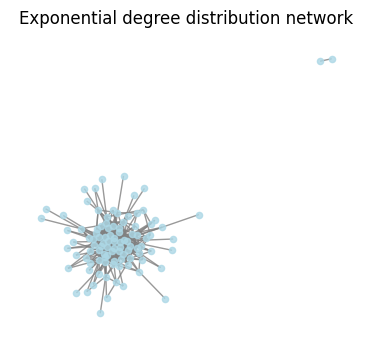

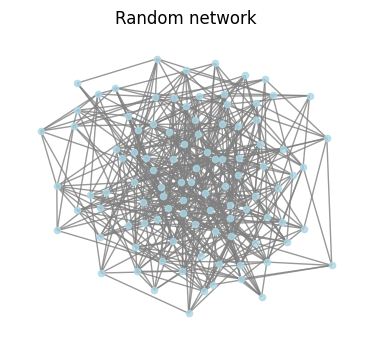

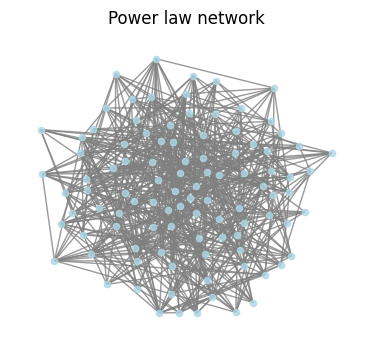

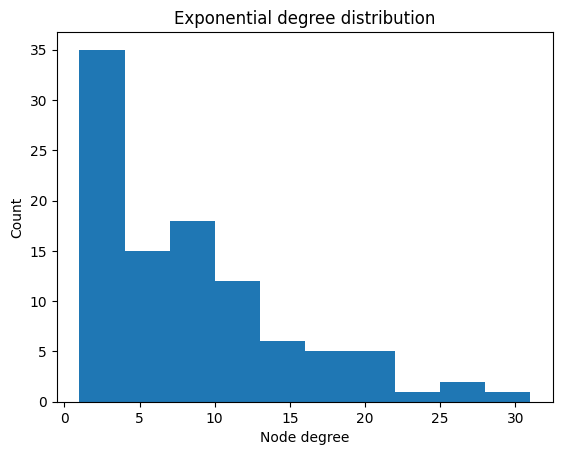

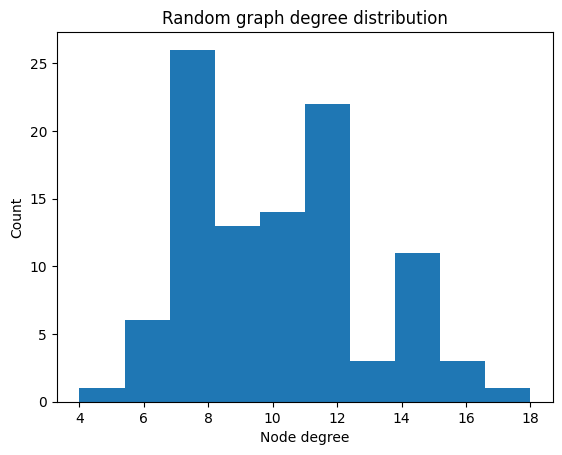

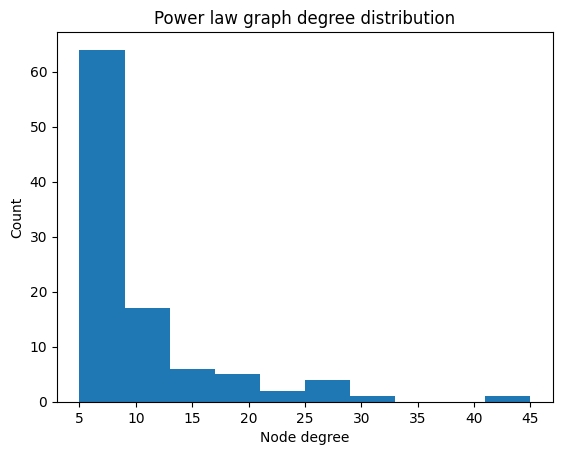

In [ ]:
# plotting for presentation visuals
with open('figure_data/dsr_network_viz.pkl', 'wb') as f:
    pickle.dump({
        'adj_exp': nx.to_numpy_array(G_exp),
        'adj_random': nx.to_numpy_array(G_random),
        'adj_power': nx.to_numpy_array(G_power),
    }, f)

pos = nx.spring_layout(G_exp)
plt.figure(figsize=(10, 4))
plt.subplot(121)
nx.draw(G_exp, pos, node_color='lightblue', node_size=20, alpha=0.8, edge_color='gray')
plt.title("Exponential degree distribution network")
plt.show()

pos = nx.spring_layout(G_random)
plt.figure(figsize=(10, 4))
plt.subplot(121)
nx.draw(G_random, pos, node_color='lightblue', node_size=20, alpha=0.8, edge_color='gray')
plt.title("Random network")
plt.show()

pos = nx.spring_layout(G_power)
plt.figure(figsize=(10, 4))
plt.subplot(121)
nx.draw(G_random, pos, node_color='lightblue', node_size=20, alpha=0.8, edge_color='gray')
plt.title("Power law network")
plt.show()

### plot histograms of degree distribution
plt.hist([d for n,d  in G_exp.degree()])
plt.title("Exponential degree distribution")
plt.xlabel("Node degree")
plt.ylabel("Count")
plt.show()

plt.hist([d for n,d  in G_random.degree()])
plt.title("Random graph degree distribution")
plt.xlabel("Node degree")
plt.ylabel("Count")
plt.show()

plt.hist([d for n,d  in G_power.degree()])
plt.title("Power law graph degree distribution")
plt.xlabel("Node degree")
plt.ylabel("Count")
plt.show()

Running iteration 1/10...
Running iteration 2/10...
Running iteration 3/10...
Running iteration 4/10...
Running iteration 5/10...
Running iteration 6/10...
Running iteration 7/10...
Running iteration 8/10...
Running iteration 9/10...
Running iteration 10/10...


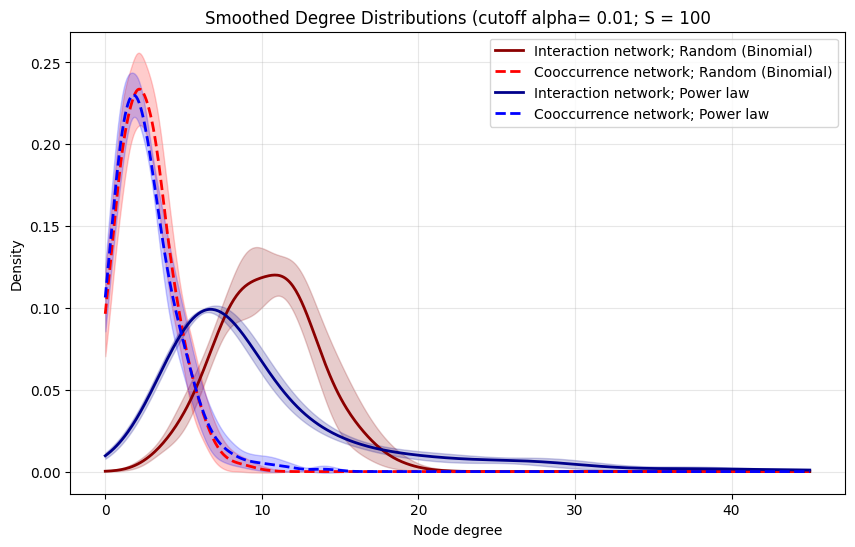

In [ ]:
# Smoothed density plot with error bands from 10 iterations
n_iterations = 10
interactFactor = 1/5
pPositive = 0.1

interactStren = alpha * interactFactor

# Initialize storage for KDE values across iterations
kde_values = {
    'rand_interact': [],
    'rand_cooc': [],
    'pow_interact': [],
    'pow_cooc': []
}

max_degree = 0

# Run 10 iterations
for iteration in range(n_iterations):
    print(f"Running iteration {iteration + 1}/{n_iterations}...")
    
    # Generate new networks for this iteration
    G_power_iter, mx_power_iter = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type="power", expected_degree=10, pPositive=pPositive)
    G_random_iter, mx_random_iter = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type="random", expected_degree=10, pPositive=pPositive)
    
    # Get co-occurrence networks
    network_pow_iter, G_coocc_pow_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_power_iter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    network_rand_iter, G_rand_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_random_iter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    
    # Get degrees
    deg_pow_interact_iter = np.array([d for n, d in G_power_iter.degree()])
    deg_pow_cooc_iter = np.array([d for n, d in G_coocc_pow_iter.degree()])
    deg_rand_interact_iter = np.array([d for n, d in G_random_iter.degree()])
    deg_rand_cooc_iter = np.array([d for n, d in G_rand_coocc_iter.degree()])

    max_degree_temp = max([deg_pow_interact_iter.max(), deg_pow_cooc_iter.max(), deg_rand_interact_iter.max(), deg_rand_cooc_iter.max()])
    max_degree = max(max_degree_temp, max_degree)
    x_range = np.linspace(0, max_degree, 500)

    # Create KDEs and evaluate on x_range
    kde_values['rand_interact'].append(gaussian_kde(deg_rand_interact_iter)(x_range))
    kde_values['rand_cooc'].append(gaussian_kde(deg_rand_cooc_iter)(x_range))
    kde_values['pow_interact'].append(gaussian_kde(deg_pow_interact_iter)(x_range))
    kde_values['pow_cooc'].append(gaussian_kde(deg_pow_cooc_iter)(x_range))

x_range = np.linspace(0, max_degree, 500)

# Convert to arrays and calculate mean and std
kde_arrays = {k: np.array(v) for k, v in kde_values.items()}
kde_means = {k: np.mean(v, axis=0) for k, v in kde_arrays.items()}
kde_stds = {k: np.std(v, axis=0) for k, v in kde_arrays.items()}

with open('figure_data/dsr_kde_randpow.pkl', 'wb') as f:
    pickle.dump({
        'kde_means': kde_means,
        'kde_stds': kde_stds,
        'x_range': x_range,
        'nSpec': nSpec,
        'cutoffalpha': cutoffalpha,
    }, f)

# Plot with shaded error bands
plt.figure(figsize=(10, 6))

# Random interaction
plt.plot(x_range, kde_means['rand_interact'], label="Interaction network; Random (Binomial)", 
         color='darkred', linewidth=2)
plt.fill_between(x_range, 
                 kde_means['rand_interact'] - kde_stds['rand_interact'],
                 kde_means['rand_interact'] + kde_stds['rand_interact'],
                 color='darkred', alpha=0.2)

# Random co-occurrence
plt.plot(x_range, kde_means['rand_cooc'], label="Cooccurrence network; Random (Binomial)", 
         color='red', linewidth=2, linestyle='--')
plt.fill_between(x_range, 
                 kde_means['rand_cooc'] - kde_stds['rand_cooc'],
                 kde_means['rand_cooc'] + kde_stds['rand_cooc'],
                 color='red', alpha=0.2)

# Power law interaction
plt.plot(x_range, kde_means['pow_interact'], label="Interaction network; Power law", 
         color='darkblue', linewidth=2)
plt.fill_between(x_range, 
                 kde_means['pow_interact'] - kde_stds['pow_interact'],
                 kde_means['pow_interact'] + kde_stds['pow_interact'],
                 color='darkblue', alpha=0.2)

# Power law co-occurrence
plt.plot(x_range, kde_means['pow_cooc'], label="Cooccurrence network; Power law", 
         color='blue', linewidth=2, linestyle='--')
plt.fill_between(x_range, 
                 kde_means['pow_cooc'] - kde_stds['pow_cooc'],
                 kde_means['pow_cooc'] + kde_stds['pow_cooc'],
                 color='blue', alpha=0.2)

plt.xlabel('Node degree')
plt.ylabel('Density')
plt.title(f'Smoothed Degree Distributions (cutoff alpha= {np.round(cutoffalpha,2)}; S = {nSpec}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# same plot but for hub, mod, and nested
n_iterations = 10
interactFactor = 1/5
interactStren = alpha * interactFactor
pPositive = 0.1

# Initialize storage for KDE values across iterations
kde_values = {
    'mod_interact': [],
    'mod_cooc': [],
    'hub_interact': [],
    'hub_cooc': [],
    'nested_interact': [],
    'nested_cooc': []
}

max_degree = 0
# Run 10 iterations
for iteration in range(n_iterations):
    print(f"Running iteration {iteration + 1}/{n_iterations}...")
    
    # Generate new networks for this iteration
    mx_mod_inter = metaCommunityMx.generateModularMatrix(interactStren, pPositive, nSpec, pWithinMod, pBetweenMod, nModules)
    mx_hub_inter = metaCommunityMx.generateHubMatrix(interactStren, pPositive, nSpec, pWithinModHub, pBetweenModHub, nModules, pHub)
    mx_nested_inter = metaCommunityMx.getNestedMutual(maxInteractionStrength = interactStren, nSpecies = nSpec, pInterInteract = pInterInteract, pIntraInteract = pIntraInteract, pPositive = pPositive)

    G_mod_inter = nx.from_numpy_array(mx_mod_inter)
    G_hub_inter = nx.from_numpy_array(mx_hub_inter)
    G_nested_inter = nx.from_numpy_array(mx_nested_inter)

    # Get co-occurrence networks
    print("mod")
    network_mod_iter, G_coocc_mod_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_mod_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, 
                                                                            numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    print("Hub")
    network_hub_iter, G_hub_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_hub_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, 
                                                                            numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    print("Nested")
    network_nested_iter, G_nested_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_nested_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, 
                                                                                  numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)

    # Get degrees
    deg_mod_interact_iter = np.array([d for n, d in G_mod_inter.degree()])
    deg_mod_cooc_iter = np.array([d for n, d in G_coocc_mod_iter.degree()])

    deg_hub_interact_iter = np.array([d for n, d in G_hub_inter.degree()])
    deg_hub_cooc_iter = np.array([d for n, d in G_hub_coocc_iter.degree()])

    deg_nested_interact_iter = np.array([d for n, d in G_nested_inter.degree()])
    deg_nested_cooc_iter = np.array([d for n, d in G_nested_coocc_iter.degree()])

    max_degree_temp = max([deg_mod_interact_iter.max(), deg_mod_cooc_iter.max(), deg_hub_interact_iter.max(), deg_hub_cooc_iter.max(), deg_nested_interact_iter.max(), deg_nested_cooc_iter.max()])
    max_degree = max(max_degree_temp, max_degree)
    x_range = np.linspace(0, max_degree, 500)

    # Create KDEs and evaluate on x_range
    kde_values['mod_interact'].append(gaussian_kde(deg_mod_interact_iter)(x_range))
    kde_values['mod_cooc'].append(gaussian_kde(deg_mod_cooc_iter)(x_range))
    kde_values['hub_interact'].append(gaussian_kde(deg_hub_interact_iter)(x_range))
    kde_values['hub_cooc'].append(gaussian_kde(deg_hub_cooc_iter)(x_range))
    kde_values['nested_interact'].append(gaussian_kde(deg_nested_interact_iter)(x_range))
    kde_values['nested_cooc'].append(gaussian_kde(deg_nested_cooc_iter)(x_range))



Running iteration 1/10...
mod
Hub
Nested
System did not converge. Trying with max_step=1.0
Did not reach equilibrium; run with higher tmax; System may not converge if interactions cause positive feedback loop.
7.499696363847445e+16
Max pop size over 10^8 -- system did not converge
1.8383818936729482e+17
System did not converge. Trying with max_step=1.0
Did not reach equilibrium; run with higher tmax; System may not converge if interactions cause positive feedback loop.
1.1906505901883315e+17
Max pop size over 10^8 -- system did not converge
2.949489095591474e+17
System did not converge. Trying with max_step=1.0
Did not reach equilibrium; run with higher tmax; System may not converge if interactions cause positive feedback loop.
6.882278182163328e+16
Max pop size over 10^8 -- system did not converge
2.4905550212234637e+17
System did not converge. Trying with max_step=1.0
Did not reach equilibrium; run with higher tmax; System may not converge if interactions cause positive feedback loop

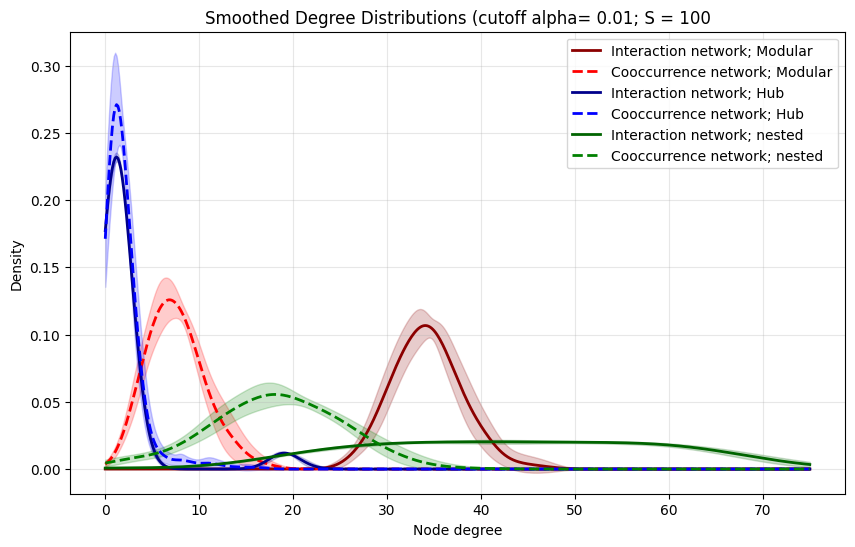

In [ ]:

# Convert to arrays and calculate mean and std
kde_arrays = {k: np.array(v) for k, v in kde_values.items()}
kde_means = {k: np.mean(v, axis=0) for k, v in kde_arrays.items()}
kde_stds = {k: np.std(v, axis=0) for k, v in kde_arrays.items()}

# Find max degree across all data for consistent x_range
x_range = np.linspace(0, max_degree, 500)

with open('figure_data/dsr_kde_modhubnested.pkl', 'wb') as f:
    pickle.dump({
        'kde_means': kde_means,
        'kde_stds': kde_stds,
        'x_range': x_range,
        'nSpec': nSpec,
        'cutoffalpha': cutoffalpha,
    }, f)

# Plot with shaded error bands
plt.figure(figsize=(10, 6))

# mod interaction
plt.plot(x_range, kde_means['mod_interact'], label="Interaction network; Modular", 
         color='darkred', linewidth=2)
plt.fill_between(x_range, 
                 kde_means['mod_interact'] - kde_stds['mod_interact'],
                 kde_means['mod_interact'] + kde_stds['mod_interact'],
                 color='darkred', alpha=0.2)

# mod co-occurrence
plt.plot(x_range, kde_means['mod_cooc'], label="Cooccurrence network; Modular", 
         color='red', linewidth=2, linestyle='--')
plt.fill_between(x_range, 
                 kde_means['mod_cooc'] - kde_stds['mod_cooc'],
                 kde_means['mod_cooc'] + kde_stds['mod_cooc'],
                 color='red', alpha=0.2)

# hub interaction
plt.plot(x_range, kde_means['hub_interact'], label="Interaction network; Hub", 
         color='darkblue', linewidth=2)
plt.fill_between(x_range, 
                 kde_means['hub_interact'] - kde_stds['hub_interact'],
                 kde_means['hub_interact'] + kde_stds['hub_interact'],
                 color='darkblue', alpha=0.2)

# hub co-occurrence
plt.plot(x_range, kde_means['hub_cooc'], label="Cooccurrence network; Hub", 
         color='blue', linewidth=2, linestyle='--')
plt.fill_between(x_range, 
                 kde_means['hub_cooc'] - kde_stds['hub_cooc'],
                 kde_means['hub_cooc'] + kde_stds['hub_cooc'],
                 color='blue', alpha=0.2)

# nested interaction
plt.plot(x_range, kde_means['nested_interact'], label="Interaction network; nested", 
         color='darkgreen', linewidth=2)
plt.fill_between(x_range, 
                 kde_means['nested_interact'] - kde_stds['nested_interact'],
                 kde_means['nested_interact'] + kde_stds['nested_interact'],
                 color='darkgreen', alpha=0.2)

# nested co-occurrence
plt.plot(x_range, kde_means['nested_cooc'], label="Cooccurrence network; nested", 
         color='green', linewidth=2, linestyle='--')
plt.fill_between(x_range, 
                 kde_means['nested_cooc'] - kde_stds['nested_cooc'],
                 kde_means['nested_cooc'] + kde_stds['nested_cooc'],
                 color='green', alpha=0.2)

plt.xlabel('Node degree')
plt.ylabel('Density')
plt.title(f'Smoothed Degree Distributions (cutoff alpha= {np.round(cutoffalpha,2)}; S = {nSpec}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
# Side-by-side plots: Interaction networks and Cooccurrence networks separated
# all 5 network types

interactFactor = 1/5
n_iterations = 10
interactStren = alpha * interactFactor
pPositive = 0.1

# 10/(nSpec-1 * 2) is the conversion of expected degree of 10 to the probability of interaction for a random matrix. dividing by 2 because interactions are not directed
# calculate total interactions (10*nspec) and possible interactions (nspec*(nspec-1)) and divide them
modHubParms = metaCommunityMx.hubMxMatching(nSpec, nModules, pInteractRandom = 10/((nSpec-1)))

# Initialize storage for ALL network types
all_kde_values = {
    'rand_interact': [], 'rand_cooc': [],
    'pow_interact': [], 'pow_cooc': [],
    'mod_interact': [], 'mod_cooc': [],
    'hub_interact': [], 'hub_cooc': []#,
#    'nested_interact': [], 'nested_cooc': []
}

# Run one iteration to get max degrees
# Generate all network types
G_power_iter, mx_power_iter = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type="power", expected_degree=10, pPositive=pPositive)
G_random_iter, mx_random_iter = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type="random", expected_degree=10, pPositive=pPositive)
mx_mod_inter = metaCommunityMx.generateModularMatrix(interactStren, pPositive, nSpec, modHubParms["pWithinMod"], modHubParms["pBetweenMod"], nModules)
mx_hub_inter = metaCommunityMx.generateHubMatrix(interactStren, pPositive, nSpec, modHubParms["pWithinModHub"], modHubParms["pBetweenModHub"], nModules, modHubParms["pHub"])
#mx_nested_inter = metaCommunityMx.getNestedMutual(maxInteractionStrength=interactStren, nSpecies=nSpec, pInterInteract=pInterInteract, pIntraInteract=pIntraInteract, pPositive=pPositive)

G_mod_inter = nx.from_numpy_array(mx_mod_inter)
G_hub_inter = nx.from_numpy_array(mx_hub_inter)
#G_nested_inter = nx.from_numpy_array(mx_nested_inter)

# Get co-occurrence networks
network_pow_iter, G_coocc_pow_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_power_iter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
network_rand_iter, G_rand_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_random_iter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
network_mod_iter, G_coocc_mod_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_mod_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
network_hub_iter, G_hub_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_hub_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
#network_nested_iter, G_nested_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_nested_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)

# Get degrees
deg_pow_interact_iter = np.array([d for n, d in G_power_iter.degree()])
deg_pow_cooc_iter = np.array([d for n, d in G_coocc_pow_iter.degree()])
deg_rand_interact_iter = np.array([d for n, d in G_random_iter.degree()])
deg_rand_cooc_iter = np.array([d for n, d in G_rand_coocc_iter.degree()])
deg_mod_interact_iter = np.array([d for n, d in G_mod_inter.degree()])
deg_mod_cooc_iter = np.array([d for n, d in G_coocc_mod_iter.degree()])
deg_hub_interact_iter = np.array([d for n, d in G_hub_inter.degree()])
deg_hub_cooc_iter = np.array([d for n, d in G_hub_coocc_iter.degree()])
#deg_nested_interact_iter = np.array([d for n, d in G_nested_inter.degree()])
#deg_nested_cooc_iter = np.array([d for n, d in G_nested_coocc_iter.degree()])

# Update max degree
max_degree_inter = max([
    deg_pow_interact_iter.max(),
    deg_rand_interact_iter.max(),
    deg_mod_interact_iter.max(),
    deg_hub_interact_iter.max()#,
#    deg_nested_interact_iter.max(),
])
max_degree_cooc = max([
    deg_pow_cooc_iter.max(),
    deg_rand_cooc_iter.max(),
    deg_mod_cooc_iter.max(),
    deg_hub_cooc_iter.max()#,
#    deg_nested_cooc_iter.max()
])
max_degree_inter = max_degree_inter + 10
max_degree_cooc = max_degree_cooc + 10

# Create x_range after all iterations
x_range_inter = np.linspace(0, max_degree_inter, 500)
x_range_cooc = np.linspace(0, max_degree_cooc, 500)

# Now run iterations to get curves with confidence intervals (KDE values with consistent x_range)
for iteration in range(n_iterations):
    print(f"iteration {iteration + 1}/{n_iterations}...")
    
    # Generate networks
    G_power_iter, mx_power_iter = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type="power", expected_degree=10, pPositive=pPositive)
    G_random_iter, mx_random_iter = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type="random", expected_degree=10, pPositive=pPositive)
    mx_mod_inter = metaCommunityMx.generateModularMatrix(interactStren, pPositive, nSpec, modHubParms["pWithinMod"], modHubParms["pBetweenMod"], nModules)
    mx_hub_inter = metaCommunityMx.generateHubMatrix(interactStren, pPositive, nSpec, modHubParms["pWithinModHub"], modHubParms["pBetweenModHub"], nModules, modHubParms["pHub"])
    #mx_nested_inter = metaCommunityMx.getNestedMutual(maxInteractionStrength=interactStren, nSpecies=nSpec, pInterInteract=pInterInteract, pIntraInteract=pIntraInteract, pPositive=pPositive)
    
    G_mod_inter = nx.from_numpy_array(mx_mod_inter)
    G_hub_inter = nx.from_numpy_array(mx_hub_inter)
    # G_nested_inter = nx.from_numpy_array(mx_nested_inter)
    
    # Get co-occurrence networks
    network_pow_iter, G_coocc_pow_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_power_iter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    network_rand_iter, G_rand_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_random_iter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    network_mod_iter, G_coocc_mod_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_mod_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    network_hub_iter, G_hub_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_hub_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    #network_nested_iter, G_nested_coocc_iter = run_cooccurrence.get_coocc_network(interactionMx=mx_nested_inter, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
    
    # Get degrees
    deg_pow_interact_iter = np.array([d for n, d in G_power_iter.degree()])
    deg_pow_cooc_iter = np.array([d for n, d in G_coocc_pow_iter.degree()])
    deg_rand_interact_iter = np.array([d for n, d in G_random_iter.degree()])
    deg_rand_cooc_iter = np.array([d for n, d in G_rand_coocc_iter.degree()])
    deg_mod_interact_iter = np.array([d for n, d in G_mod_inter.degree()])
    deg_mod_cooc_iter = np.array([d for n, d in G_coocc_mod_iter.degree()])
    deg_hub_interact_iter = np.array([d for n, d in G_hub_inter.degree()])
    deg_hub_cooc_iter = np.array([d for n, d in G_hub_coocc_iter.degree()])
    #deg_nested_interact_iter = np.array([d for n, d in G_nested_inter.degree()])
    #deg_nested_cooc_iter = np.array([d for n, d in G_nested_coocc_iter.degree()])
    
    # Create KDEs 
    all_kde_values['rand_interact'].append(gaussian_kde(deg_rand_interact_iter)(x_range_inter))
    all_kde_values['rand_cooc'].append(gaussian_kde(deg_rand_cooc_iter)(x_range_cooc))
    all_kde_values['pow_interact'].append(gaussian_kde(deg_pow_interact_iter)(x_range_inter))
    all_kde_values['pow_cooc'].append(gaussian_kde(deg_pow_cooc_iter)(x_range_cooc))
    all_kde_values['mod_interact'].append(gaussian_kde(deg_mod_interact_iter)(x_range_inter))
    all_kde_values['mod_cooc'].append(gaussian_kde(deg_mod_cooc_iter)(x_range_cooc))
    all_kde_values['hub_interact'].append(gaussian_kde(deg_hub_interact_iter)(x_range_inter))
    all_kde_values['hub_cooc'].append(gaussian_kde(deg_hub_cooc_iter)(x_range_cooc))
    #all_kde_values['nested_interact'].append(gaussian_kde(deg_nested_interact_iter)(x_range_inter))
    #all_kde_values['nested_cooc'].append(gaussian_kde(deg_nested_cooc_iter)(x_range_cooc))

# Convert to arrays and calculate mean and std
all_kde_arrays = {k: np.array(v) for k, v in all_kde_values.items()}
all_kde_means = {k: np.mean(v, axis=0) for k, v in all_kde_arrays.items()}
all_kde_stds = {k: np.std(v, axis=0) for k, v in all_kde_arrays.items()}

iteration 1/10...
iteration 2/10...
iteration 3/10...
iteration 4/10...
iteration 5/10...
iteration 6/10...
iteration 7/10...
iteration 8/10...
iteration 9/10...
iteration 10/10...


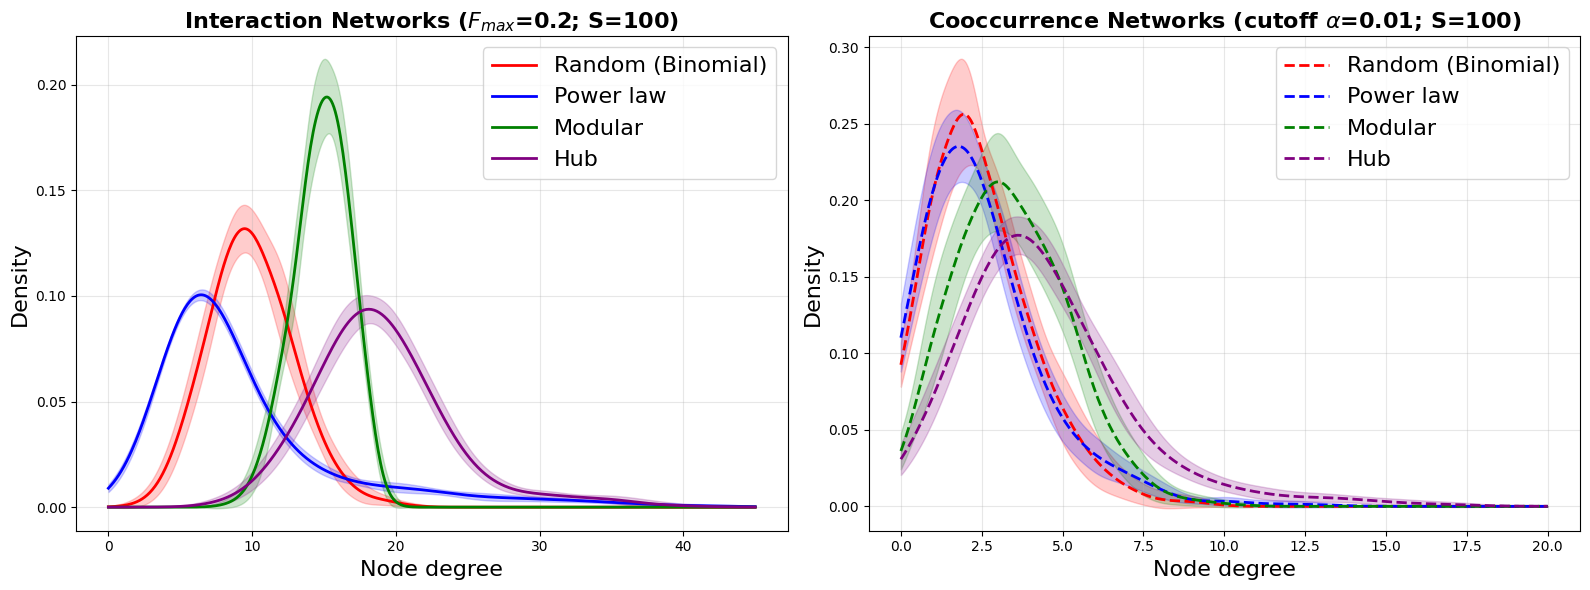

In [ ]:
#plot
with open('figure_data/dsr_kde_sidebyside.pkl', 'wb') as f:
    pickle.dump({
        'all_kde_means': all_kde_means,
        'all_kde_stds': all_kde_stds,
        'x_range_inter': x_range_inter,
        'x_range_cooc': x_range_cooc,
        'nSpec': nSpec,
        'cutoffalpha': cutoffalpha,
        'interactFactor': interactFactor,
    }, f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Interaction Networks
ax1.plot(x_range_inter, all_kde_means['rand_interact'], label="Random (Binomial)", color='red', linewidth=2)
ax1.fill_between(x_range_inter, all_kde_means['rand_interact'] - all_kde_stds['rand_interact'],
                 all_kde_means['rand_interact'] + all_kde_stds['rand_interact'], color='red', alpha=0.2)

ax1.plot(x_range_inter, all_kde_means['pow_interact'], label="Power law", color='blue', linewidth=2)
ax1.fill_between(x_range_inter, all_kde_means['pow_interact'] - all_kde_stds['pow_interact'],
                 all_kde_means['pow_interact'] + all_kde_stds['pow_interact'], color='blue', alpha=0.2)

ax1.plot(x_range_inter, all_kde_means['mod_interact'], label="Modular", color='green', linewidth=2)
ax1.fill_between(x_range_inter, all_kde_means['mod_interact'] - all_kde_stds['mod_interact'],
                 all_kde_means['mod_interact'] + all_kde_stds['mod_interact'], color='green', alpha=0.2)

ax1.plot(x_range_inter, all_kde_means['hub_interact'], label="Hub", color='purple', linewidth=2)
ax1.fill_between(x_range_inter, all_kde_means['hub_interact'] - all_kde_stds['hub_interact'],
                 all_kde_means['hub_interact'] + all_kde_stds['hub_interact'], color='purple', alpha=0.2)

# ax1.plot(x_range_inter, all_kde_means['nested_interact'], label="Nested", color='orange', linewidth=2)
# ax1.fill_between(x_range_inter, all_kde_means['nested_interact'] - all_kde_stds['nested_interact'],
#                  all_kde_means['nested_interact'] + all_kde_stds['nested_interact'], color='orange', alpha=0.2)

ax1.set_xlabel('Node degree', fontsize=16)
ax1.set_ylabel('Density', fontsize=16)
ax1.set_title(f'Interaction Networks ($F_{{max}}$={np.round(interactFactor,2)}; S={nSpec})', fontsize=16, fontweight='bold')
ax1.legend(loc='best', fontsize=16)
ax1.grid(alpha=0.3)

# Cooccurrence Networks
ax2.plot(x_range_cooc, all_kde_means['rand_cooc'], label="Random (Binomial)", color='red', linewidth=2, linestyle='--')
ax2.fill_between(x_range_cooc, all_kde_means['rand_cooc'] - all_kde_stds['rand_cooc'],
                 all_kde_means['rand_cooc'] + all_kde_stds['rand_cooc'], color='red', alpha=0.2)

ax2.plot(x_range_cooc, all_kde_means['pow_cooc'], label="Power law", color='blue', linewidth=2, linestyle='--')
ax2.fill_between(x_range_cooc, all_kde_means['pow_cooc'] - all_kde_stds['pow_cooc'],
                 all_kde_means['pow_cooc'] + all_kde_stds['pow_cooc'], color='blue', alpha=0.2)

ax2.plot(x_range_cooc, all_kde_means['mod_cooc'], label="Modular", color='green', linewidth=2, linestyle='--')
ax2.fill_between(x_range_cooc, all_kde_means['mod_cooc'] - all_kde_stds['mod_cooc'],
                 all_kde_means['mod_cooc'] + all_kde_stds['mod_cooc'], color='green', alpha=0.2)

ax2.plot(x_range_cooc, all_kde_means['hub_cooc'], label="Hub", color='purple', linewidth=2, linestyle='--')
ax2.fill_between(x_range_cooc, all_kde_means['hub_cooc'] - all_kde_stds['hub_cooc'],
                 all_kde_means['hub_cooc'] + all_kde_stds['hub_cooc'], color='purple', alpha=0.2)

# ax2.plot(x_range_cooc, all_kde_means['nested_cooc'], label="Nested", color='orange', linewidth=2, linestyle='--')
# ax2.fill_between(x_range_cooc, all_kde_means['nested_cooc'] - all_kde_stds['nested_cooc'],
#                  all_kde_means['nested_cooc'] + all_kde_stds['nested_cooc'], color='orange', alpha=0.2)

ax2.set_xlabel('Node degree', fontsize=16)
ax2.set_ylabel('Density', fontsize=16)
ax2.set_title(f'Cooccurrence Networks (cutoff $\\alpha$={np.round(cutoffalpha,2)}; S={nSpec})', fontsize=16, fontweight='bold')
ax2.legend(loc='best', fontsize = 16)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Rank comparison plots AND degree comparison plots for all 5 network types
# Generate one realization of each network type
interactFactor = 1/5
interactStren = alpha * interactFactor
pPositive = 0.1
modHubParms = metaCommunityMx.hubMxMatching(nSpec, nModules, pInteractRandom = 10/((nSpec-1)))

# Generate all network types
G_power, mx_power = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type="power", expected_degree=10, pPositive=pPositive)
G_random, mx_random = metaCommunityMx.getPowerOrExpMatrix(nSpec, interactStren, type="random", expected_degree=10, pPositive=pPositive)
mx_mod = metaCommunityMx.generateModularMatrix(interactStren, pPositive, nSpec, modHubParms["pWithinMod"], modHubParms["pBetweenMod"], nModules)
mx_hub = metaCommunityMx.generateHubMatrix(interactStren, pPositive, nSpec, modHubParms["pWithinModHub"], modHubParms["pBetweenModHub"], nModules, modHubParms["pHub"])
#mx_nested = metaCommunityMx.getNestedMutual(maxInteractionStrength=interactStren, nSpecies=nSpec, pInterInteract=pInterInteract, pIntraInteract=pIntraInteract, pPositive=pPositive)

G_mod = nx.from_numpy_array(mx_mod)
G_hub = nx.from_numpy_array(mx_hub)
#G_nested = nx.from_numpy_array(mx_nested)

# Get co-occurrence networks
print("Generating co-occurrence networks...")
network_pow, G_coocc_pow = run_cooccurrence.get_coocc_network(interactionMx=mx_power, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx=mx_random, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
network_mod, G_coocc_mod = run_cooccurrence.get_coocc_network(interactionMx=mx_mod, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
network_hub, G_hub_coocc = run_cooccurrence.get_coocc_network(interactionMx=mx_hub, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)
#network_nested, G_nested_coocc = run_cooccurrence.get_coocc_network(interactionMx=mx_nested, cutoff=None, alpha=alpha, spsamplesize=samplesize, numtrials=numtrials, b=b, tmax=200, pval_alpha=cutoffalpha)

# Get degrees and ranks for all network types
networks = {
    'Random (Binomial)': (G_random, G_rand_coocc),
    'Power law': (G_power, G_coocc_pow),
    'Modular': (G_mod, G_coocc_mod),
    'Hub': (G_hub, G_hub_coocc)#,
#    'Nested': (G_nested, G_nested_coocc)
}


Generating co-occurrence networks...


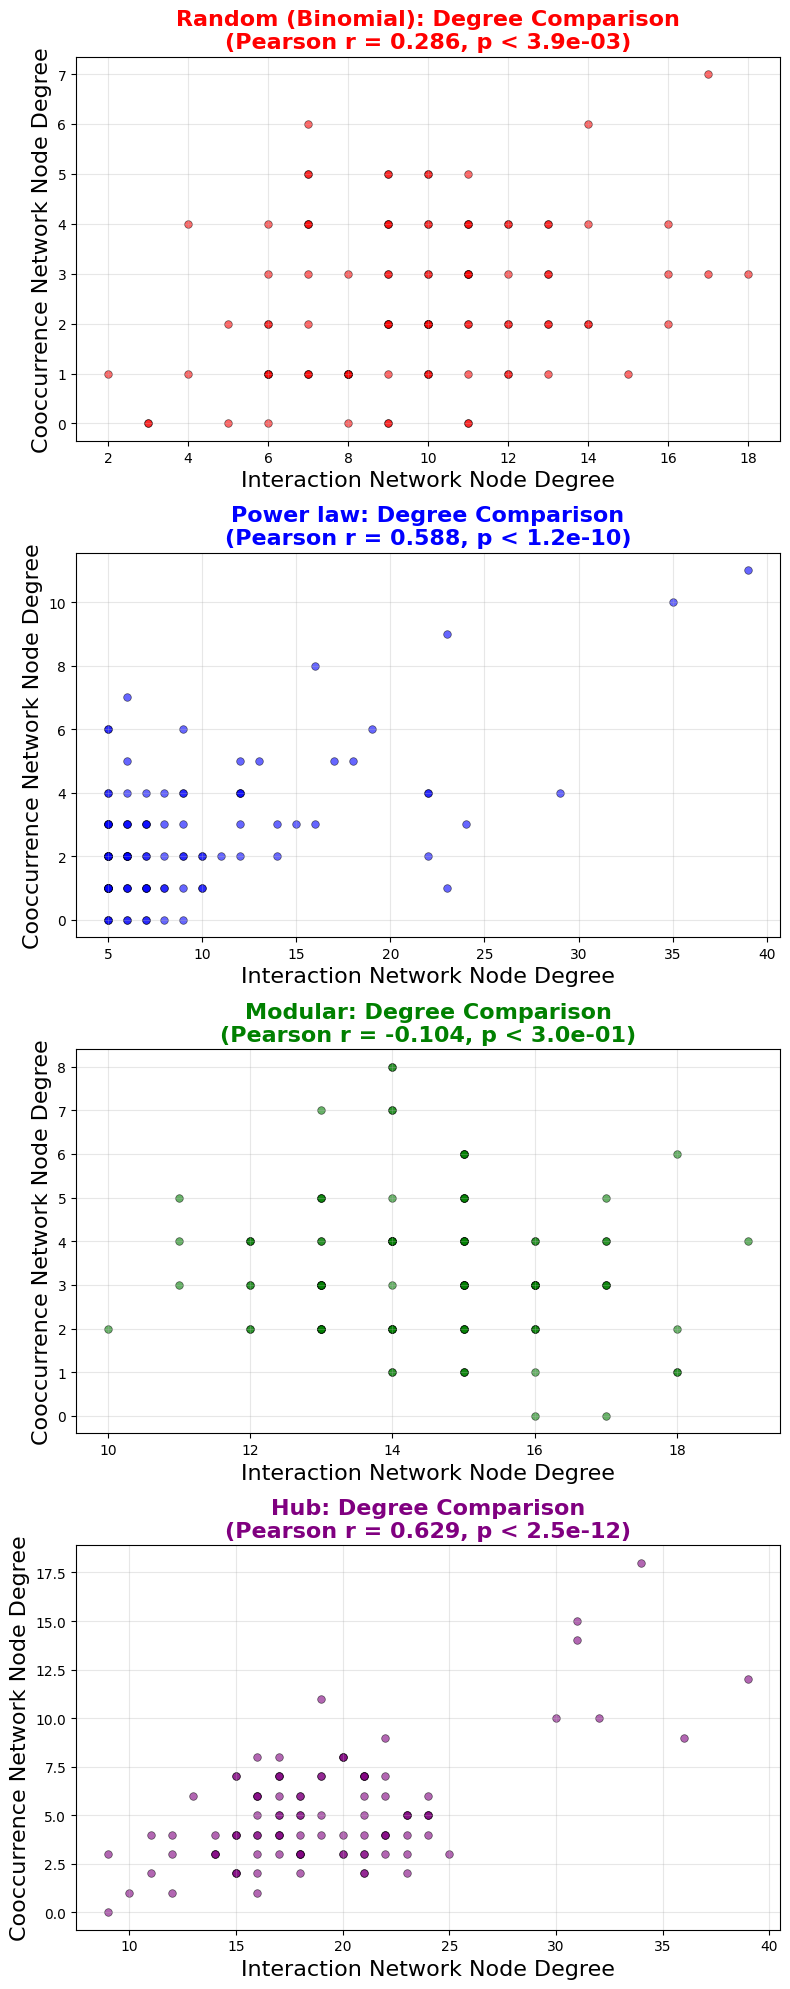

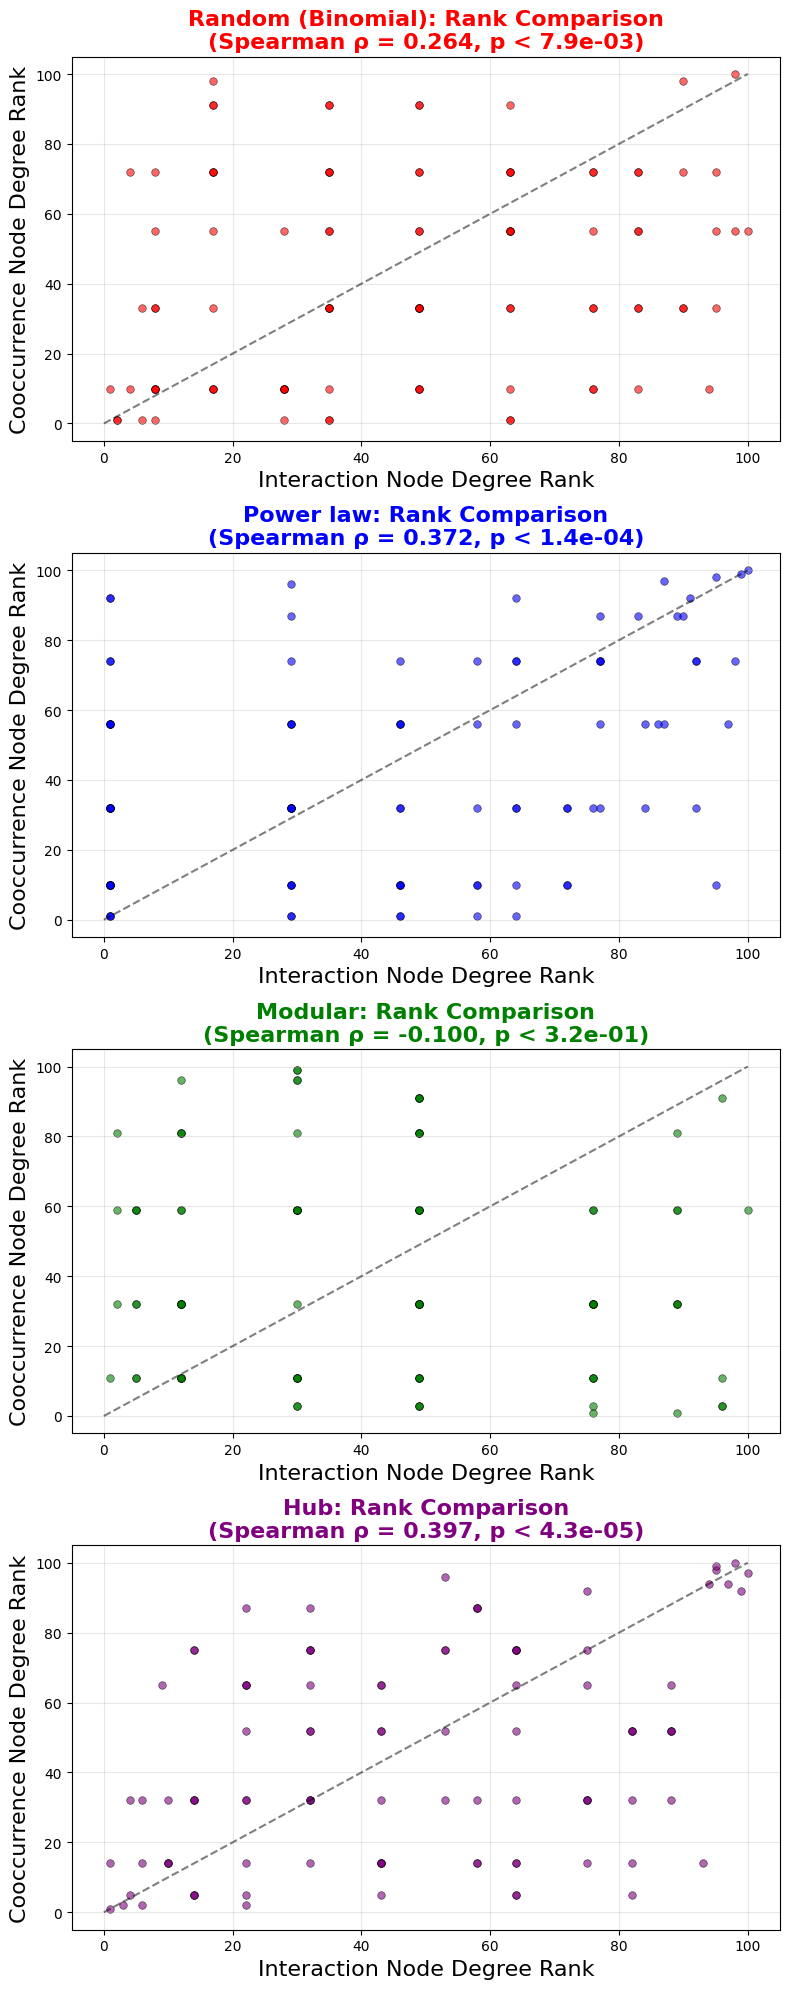

In [ ]:
# plotting
colors = {
    'Random (Binomial)': 'red',
    'Power law': 'blue',
    'Modular': 'green',
    'Hub': 'purple',
#    'Nested': 'orange'
}

_degree_rank_data = {}
for _name, (_G_inter, _G_cooc) in networks.items():
    import numpy as np
    _deg_i = np.array([d for n, d in _G_inter.degree()])
    _deg_c = np.array([d for n, d in _G_cooc.degree()])
    _degree_rank_data[_name] = {'deg_interact': _deg_i, 'deg_cooc': _deg_c}
with open('figure_data/dsr_degree_rank.pkl', 'wb') as f:
    pickle.dump({'degree_rank_data': _degree_rank_data}, f)

# Create figure with 5 rows (degree comparison)
fig, axes = plt.subplots(4, 1, figsize=(8, 20))

for idx, (network_name, (G_interact, G_cooc)) in enumerate(networks.items()):
    # Get degrees
    deg_interact = np.array([d for n, d in G_interact.degree()])
    deg_cooc = np.array([d for n, d in G_cooc.degree()])
    
    # Degree comparison
    ax_deg = axes[idx]
    ax_deg.scatter(deg_interact, deg_cooc, alpha=0.6, c=colors[network_name], s=30, edgecolors='black', linewidth=0.5)
    
    # Calculate Pearson correlation
    corr_pearson, pval_pearson = pearsonr(deg_interact, deg_cooc)
    
    # Labels and title
    ax_deg.set_xlabel('Interaction Network Node Degree', fontsize=16)
    ax_deg.set_ylabel('Cooccurrence Network Node Degree', fontsize=16)
    ax_deg.set_title(f'{network_name}: Degree Comparison\n(Pearson r = {corr_pearson:.3f}, p < {pval_pearson:.1e})', 
                     fontsize=16, fontweight='bold', color=colors[network_name])
    ax_deg.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Create figure with 5 rows (rank comparison)
fig, axes = plt.subplots(4, 1, figsize=(8, 20))

for idx, (network_name, (G_interact, G_cooc)) in enumerate(networks.items()):
    # Get degrees
    deg_interact = np.array([d for n, d in G_interact.degree()])
    deg_cooc = np.array([d for n, d in G_cooc.degree()])
    
    # Calculate ranks (using rankdata for proper ranking)
    rank_interact = rankdata(deg_interact, method='min')
    rank_cooc = rankdata(deg_cooc, method='min')
    
    # LEFT PLOT: Rank comparison
    ax_rank = axes[idx]
    ax_rank.scatter(rank_interact, rank_cooc, alpha=0.6, c=colors[network_name], s=30, edgecolors='black', linewidth=0.5)
    
    # Add diagonal reference line
    max_rank = max(rank_interact.max(), rank_cooc.max())
    ax_rank.plot([0, max_rank], [0, max_rank], 'k--', linewidth=1.5, alpha=0.5, label='1:1 line')
    
    # Calculate Spearman correlation
    corr_spearman, pval_spearman = spearmanr(rank_interact, rank_cooc)
    
    # Labels and title
    ax_rank.set_xlabel('Interaction Node Degree Rank', fontsize=16)
    ax_rank.set_ylabel('Cooccurrence Node Degree Rank', fontsize=16)
    ax_rank.set_title(f'{network_name}: Rank Comparison\n(Spearman ρ = {corr_spearman:.3f}, p < {pval_spearman:.1e})', 
                      fontsize=16, fontweight='bold', color=colors[network_name])
    ax_rank.grid(alpha=0.3)
    
plt.tight_layout()
plt.show()

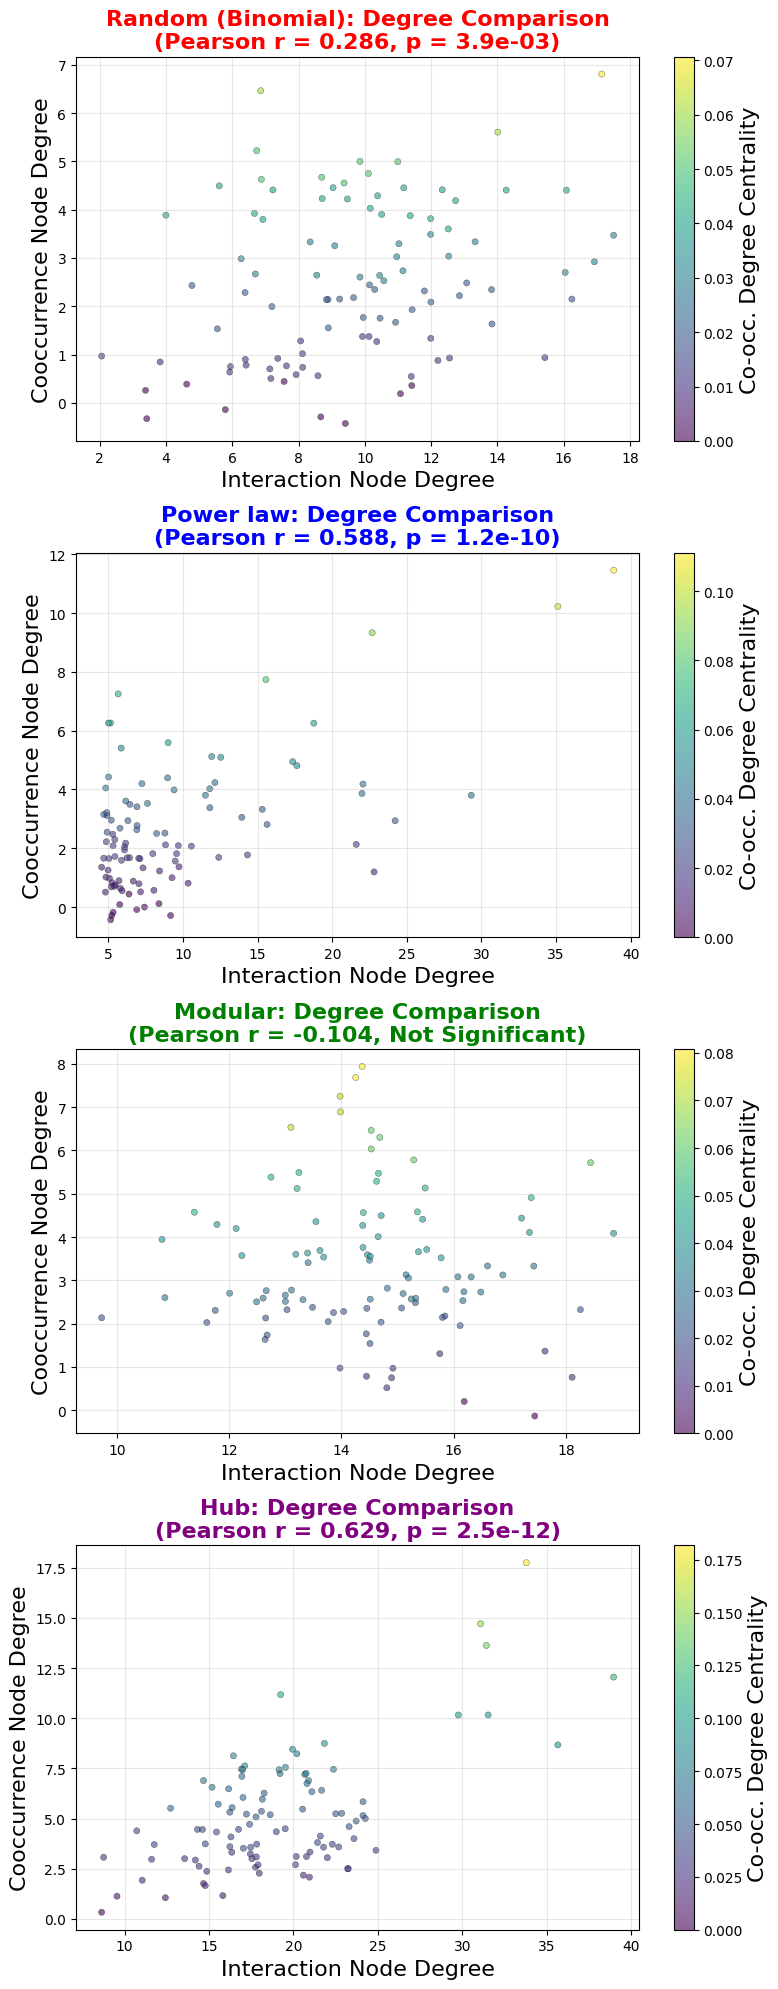

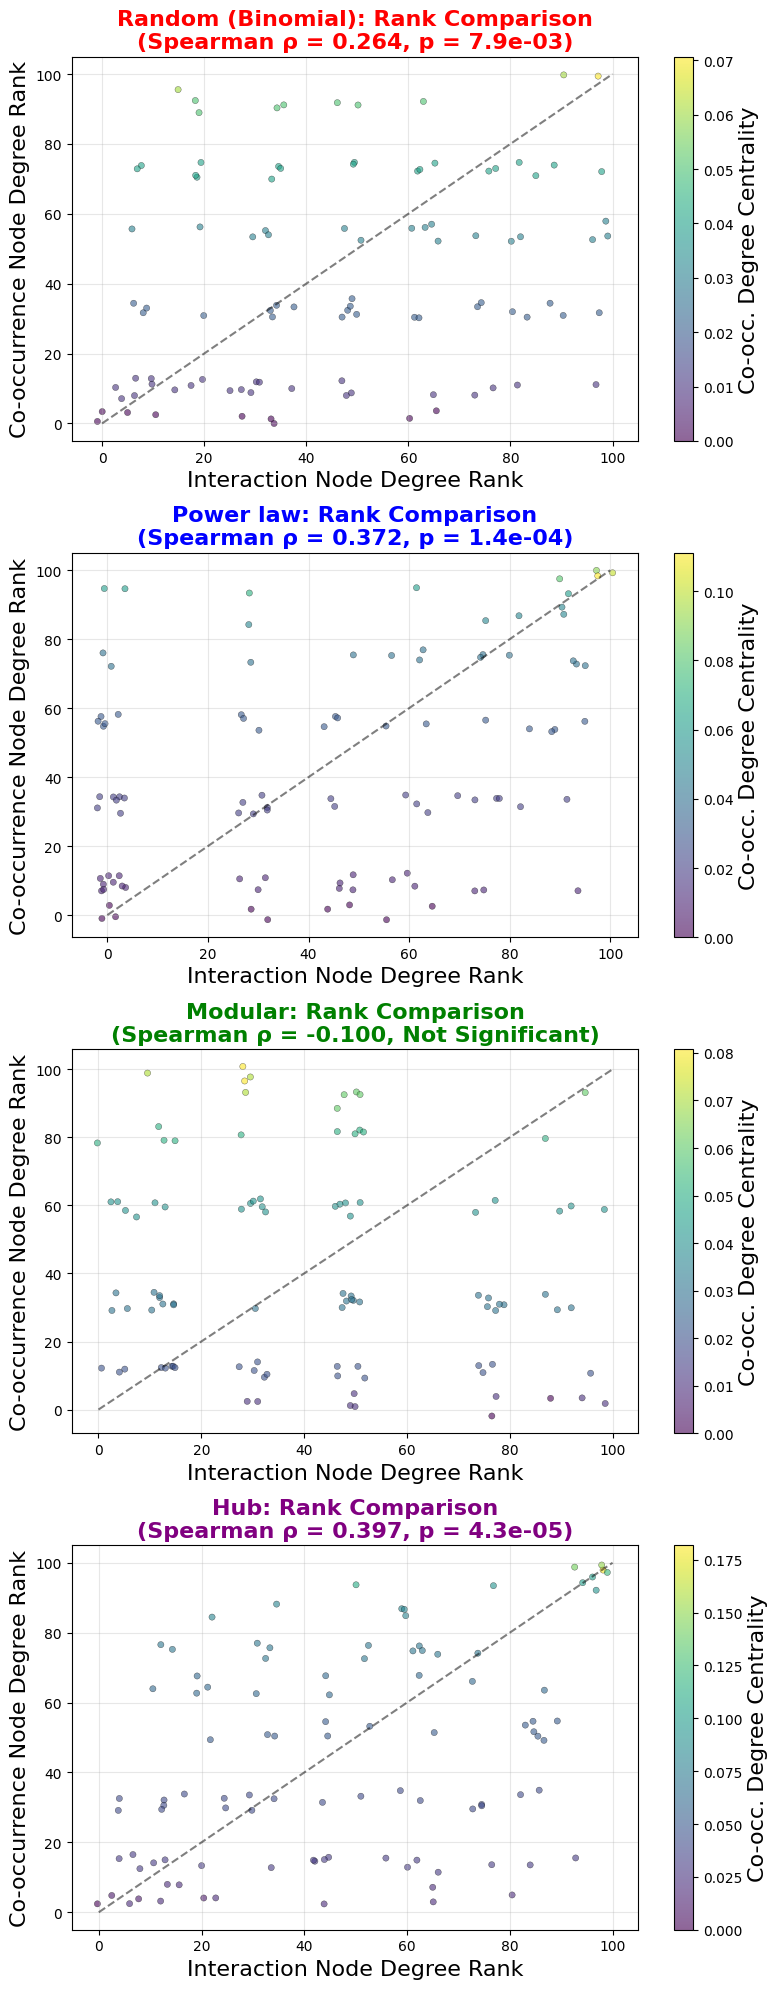

In [ ]:
# Jitter version with centrality coloring
# Points colored by co-occurrence network centrality

# options: Degree Betweenness Closeness Eigenvector
centrality_type = "Degree"

_jitter_data = {}
for _name, (_G_inter, _G_cooc) in networks.items():
    import numpy as np
    _deg_i = np.array([d for n, d in _G_inter.degree()])
    _deg_c = np.array([d for n, d in _G_cooc.degree()])
    _cent = nx.degree_centrality(_G_cooc)
    _cent_vals = np.array([_cent[n] for n in _G_cooc.nodes()])
    _jitter_data[_name] = {'deg_interact': _deg_i, 'deg_cooc': _deg_c, 'centrality_values': _cent_vals}
with open('figure_data/dsr_jitter.pkl', 'wb') as f:
    pickle.dump({'jitter_data': _jitter_data, 'centrality_type': centrality_type}, f)

fig, axes = plt.subplots(4, 1, figsize=(8, 20))

jitter_amount_deg = 0.5
jitter_amount_rank = 3

for idx, (network_name, (G_interact, G_cooc)) in enumerate(networks.items()):
    # Get degrees
    deg_interact = np.array([d for n, d in G_interact.degree()])
    deg_cooc = np.array([d for n, d in G_cooc.degree()])
    
    # Calculate centrality for co-occurrence network
    if centrality_type == "Degree":
        deg_centrality_cooc = nx.degree_centrality(G_cooc)
    elif centrality_type == "Betweenness":
        deg_centrality_cooc = nx.betweenness_centrality(G_cooc)
    elif centrality_type == "Closeness":
        deg_centrality_cooc = nx.closeness_centrality(G_cooc)
    elif centrality_type == "Eigenvector":
        deg_centrality_cooc = nx.eigenvector_centrality(G_cooc, max_iter=1000)

    centrality_values = np.array([deg_centrality_cooc[n] for n in G_cooc.nodes()])
    
    deg_interact_jitter = deg_interact + np.random.uniform(-jitter_amount_deg, jitter_amount_deg, len(deg_interact))
    deg_cooc_jitter = deg_cooc + np.random.uniform(-jitter_amount_deg, jitter_amount_deg, len(deg_cooc))
    
    # PLOT: Degree comparison with jitter, colored by centrality
    ax_deg = axes[idx]
    scatter_deg = ax_deg.scatter(deg_interact_jitter, deg_cooc_jitter, 
                                  c=centrality_values, cmap='viridis',
                                  alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
    
    # Add colorbar
    cbar_deg = plt.colorbar(scatter_deg, ax=ax_deg)
    cbar_deg.set_label(f'Co-occ. {centrality_type} Centrality', fontsize=16)
    
    # Calculate Pearson correlation (on original data, not jittered)
    corr_pearson, pval_pearson = pearsonr(deg_interact, deg_cooc)
    
    # Labels and title
    ax_deg.set_xlabel('Interaction Node Degree', fontsize=16)
    ax_deg.set_ylabel('Cooccurrence Node Degree', fontsize=16)
    if pval_pearson < 0.05:
        ax_deg.set_title(f'{network_name}: Degree Comparison\n(Pearson r = {corr_pearson:.3f}, p = {pval_pearson:.1e})', 
                     fontsize=16, fontweight='bold', color=colors[network_name])
    else:
        ax_deg.set_title(f'{network_name}: Degree Comparison\n(Pearson r = {corr_pearson:.3f}, Not Significant)', 
                     fontsize=16, fontweight='bold', color=colors[network_name])
    ax_deg.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(8, 20))

jitter_amount_deg = 0.5
jitter_amount_rank = 3

for idx, (network_name, (G_interact, G_cooc)) in enumerate(networks.items()):
    # Get degrees
    deg_interact = np.array([d for n, d in G_interact.degree()])
    deg_cooc = np.array([d for n, d in G_cooc.degree()])
    
    # Calculate centrality for co-occurrence network
    if centrality_type == "Degree":
        deg_centrality_cooc = nx.degree_centrality(G_cooc)
    elif centrality_type == "Betweenness":
        deg_centrality_cooc = nx.betweenness_centrality(G_cooc)
    elif centrality_type == "Closeness":
        deg_centrality_cooc = nx.closeness_centrality(G_cooc)
    elif centrality_type == "Eigenvector":
        deg_centrality_cooc = nx.eigenvector_centrality(G_cooc, max_iter=1000)

    centrality_values = np.array([deg_centrality_cooc[n] for n in G_cooc.nodes()])
    
    # Calculate ranks (using rankdata for proper ranking)
    rank_interact = rankdata(deg_interact, method='min')
    rank_cooc = rankdata(deg_cooc, method='min')
    
    # Add jitter
    rank_interact_jitter = rank_interact + np.random.uniform(-jitter_amount_rank, jitter_amount_rank, len(rank_interact))
    rank_cooc_jitter = rank_cooc + np.random.uniform(-jitter_amount_rank, jitter_amount_rank, len(rank_cooc))
    deg_interact_jitter = deg_interact + np.random.uniform(-jitter_amount_deg, jitter_amount_deg, len(deg_interact))
    deg_cooc_jitter = deg_cooc + np.random.uniform(-jitter_amount_deg, jitter_amount_deg, len(deg_cooc))
    
    # PLOT: Rank comparison with jitter, colored by centrality
    ax_rank = axes[idx]
    scatter_rank = ax_rank.scatter(rank_interact_jitter, rank_cooc_jitter, 
                                    c=centrality_values, cmap='viridis',
                                    alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
    
    # Add diagonal reference line
    max_rank = max(rank_interact.max(), rank_cooc.max())
    ax_rank.plot([0, max_rank], [0, max_rank], 'k--', linewidth=1.5, alpha=0.5, label='1:1 line')
    
    # Add colorbar
    cbar_rank = plt.colorbar(scatter_rank, ax=ax_rank)
    cbar_rank.set_label(f'Co-occ. {centrality_type} Centrality', fontsize=16)
    
    # Calculate Spearman correlation (on original data, not jittered)
    corr_spearman, pval_spearman = spearmanr(rank_interact, rank_cooc)
    
    # Labels and title
    ax_rank.set_xlabel('Interaction Node Degree Rank', fontsize=16)
    ax_rank.set_ylabel('Co-occurrence Node Degree Rank', fontsize=16)
    if (pval_spearman < 0.05):
        ax_rank.set_title(f'{network_name}: Rank Comparison\n(Spearman ρ = {corr_spearman:.3f}, p = {pval_spearman:.1e})', 
                      fontsize=16, fontweight='bold', color=colors[network_name])
    else:
        ax_rank.set_title(f'{network_name}: Rank Comparison\n(Spearman ρ = {corr_spearman:.3f}, Not Significant)', 
                      fontsize=16, fontweight='bold', color=colors[network_name])
    ax_rank.grid(alpha=0.3)

plt.tight_layout()
plt.show()